# Mapping Beer Flavor Space

## Density-Based and Fuzzy Clustering of Review-Derived Sensory Profiles

**By:** Jason Ye, Kenshi King, and Yuda Zhu

## 1. Introduction

Beer styles overlap: a beer can be simultaneously malty, fruity, bitter, and alcoholic. This makes beer a useful case for studying whether observations form genuinely separate groups or lie on a continuous spectrum.

### Research questions

1. Can beers be meaningfully grouped using their flavor profiles and alcohol content?
2. What broad and fine-grained flavor groupings emerge?

We answer these questions with descriptive analysis, dimension-reduction diagnostics, a K-means baseline, DBSCAN, and fuzzy C-means. The main conclusion is intentionally nuanced: the data support reproducible flavor tendencies, but not perfectly separated categories.

## 2. Dataset and Feature Meaning

The dataset combines tasting profiles and consumer-review summaries for 3,197 unique beers from 934 breweries. ABV is measured as percent alcohol by volume. The eleven sensory variables are **counts of descriptor words found in up to 25 reviews per beer**, not ratings on a common intensity scale. This distinction determines how the sensory data should be normalized.

The review averages, style labels, brewery names, descriptions, and style-level IBU ranges are retained for interpretation but are not used to fit the clusters.

Source: [Beer Profile and Ratings Data Set](https://www.kaggle.com/datasets/ruthgn/beer-profile-and-ratings-data-set)

### Imports and reproducibility settings

In [1]:
from pathlib import Path
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import cdist, pdist
from scipy.stats import spearmanr
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from skfuzzy.cluster import cmeans

RANDOM_STATE = 100
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)

### Load and inspect the source file

In [2]:
DATA_PATH = Path("beer_profile_and_ratings.csv")
beer = pd.read_csv(DATA_PATH)
SOURCE_COLUMNS = beer.columns.tolist()

print(f"Shape: {beer.shape}")
print(f"Unique beer identifiers: {beer['Beer Name (Full)'].nunique():,}")
print(f"Styles: {beer['Style'].nunique():,}")
print(f"Breweries: {beer['Brewery'].nunique():,}")
beer.head(3)

Shape: (3197, 25)
Unique beer identifiers: 3,197
Styles: 111
Breweries: 934


,Name,Style,Brewery,Beer Name (Full),Description,ABV,Min IBU,Max IBU,Astringency,Body,Alcohol,Bitter,Sweet,Sour,Salty,Fruits,Hoppy,Spices,Malty,review_aroma,review_appearance,review_palate,review_taste,review_overall,number_of_reviews
0,Amber,Altbier,Alaskan Brewing Co.,Alaskan Brewing Co. Alaskan Amber,"Notes:Richly malty and long on the palate, wit...",5.3,25,50,13,32,9,47,74,33,0,33,57,8,111,3.498994,3.636821,3.556338,3.643863,3.847082,497
1,Double Bag,Altbier,Long Trail Brewing Co.,Long Trail Brewing Co. Double Bag,"Notes:This malty, full-bodied double alt is al...",7.2,25,50,12,57,18,33,55,16,0,24,35,12,84,3.798337,3.846154,3.904366,4.024948,4.034304,481
2,Long Trail Ale,Altbier,Long Trail Brewing Co.,Long Trail Brewing Co. Long Trail Ale,Notes:Long Trail Ale is a full-bodied amber al...,5.0,25,50,14,37,6,42,43,11,0,10,54,4,62,3.409814,3.667109,3.600796,3.631300,3.830239,377


## 3. Reproducible Cleaning

We perform four explicit checks:

1. missing source values;
2. duplicate rows and duplicate beer identifiers;
3. rows with zeros across every sensory descriptor;
4. beers above 20% ABV.

The twelve empty sensory profiles cannot contribute to flavor clustering. The three beers above 20% ABV appear genuine, but we retain the original project's decision to exclude them so the analysis describes the typical beer range. Their removal is a scope choice, not a claim that they are erroneous.

In [3]:
SENSORY_COLS = [
    "Astringency", "Body", "Alcohol", "Bitter", "Sweet", "Sour",
    "Salty", "Fruits", "Hoppy", "Spices", "Malty",
]
MODEL_SENSORY_COLS = [column for column in SENSORY_COLS if column != "Salty"]
MAX_ABV = 20

empty_profile_mask = beer[SENSORY_COLS].eq(0).all(axis=1)
high_abv_mask = beer["ABV"].gt(MAX_ABV)

quality_audit = pd.Series({
    "missing source values": int(beer[SOURCE_COLUMNS].isna().sum().sum()),
    "duplicate rows": int(beer[SOURCE_COLUMNS].duplicated().sum()),
    "duplicate beer identifiers": int(beer["Beer Name (Full)"].duplicated().sum()),
    "empty sensory profiles": int(empty_profile_mask.sum()),
    f"ABV above {MAX_ABV}%": int(high_abv_mask.sum()),
})
quality_audit

missing source values          0
duplicate rows                 0
duplicate beer identifiers     0
empty sensory profiles        12
ABV above 20%                  3
dtype: int64

In [4]:
removed_rows = beer.loc[
    empty_profile_mask | high_abv_mask,
    ["Beer Name (Full)", "Style", "ABV", *SENSORY_COLS],
].copy()
removed_rows["reason"] = np.select(
    [
        empty_profile_mask[empty_profile_mask | high_abv_mask].to_numpy(),
        high_abv_mask[empty_profile_mask | high_abv_mask].to_numpy(),
    ],
    ["empty sensory profile", f"ABV above {MAX_ABV}%"],
    default="other",
)

beer_clean = beer.loc[~empty_profile_mask & ~high_abv_mask].copy()
beer_clean.index.name = "source_row"
beer_clean = beer_clean.reset_index()
beer_clean["taste_category"] = beer_clean[SENSORY_COLS].idxmax(axis=1)

assert len(beer_clean) == 3_182
assert beer_clean["source_row"].is_unique
assert not beer_clean[SENSORY_COLS].eq(0).all(axis=1).any()
assert "ABV" not in set(beer_clean["taste_category"])

print(f"Retained: {len(beer_clean):,} beers")
print(f"Removed: {len(removed_rows):,} beers")
removed_rows[["Beer Name (Full)", "Style", "ABV", "reason"]]

Retained: 3,182 beers
Removed: 15 beers


,Beer Name (Full),Style,ABV,reason
297,Schorschbräu Schorschbock 31%,Bock - Eisbock,30.86,ABV above 20%
299,Schorschbräu Schorschbock 57%,Bock - Eisbock,57.50,ABV above 20%
302,Aarhus Bryghus Black Ice,Bock - Eisbock,8.50,empty sensory profile
662,Vintage Brewing Company Summer Sahti,Farmhouse Ale - Sahti,5.40,empty sensory profile
663,Malmgårdin Panimo Malmgård Jouluolut,Farmhouse Ale - Sahti,4.50,empty sensory profile
665,Lammin Sahti Oy Puhti IV B,Farmhouse Ale - Sahti,7.00,empty sensory profile
772,Sapporo Breweries Ltd. Sapporo Mugi To Hopppu ...,Happoshu,5.00,empty sensory profile
773,Asahi Breweries Ltd Asahi Strong Off,Happoshu,7.00,empty sensory profile
774,"Orion Beer Co., Ltd. Orion Nangoku Monogatari",Happoshu,5.50,empty sensory profile
775,Suntory Akiraku,Happoshu,6.00,empty sensory profile


`Salty` is retained in the cleaned table and in descriptive summaries, but excluded from the distance-based model because it is zero for most beers and has very little variation. This decision is reported as a limitation rather than treated as universally correct.

In [5]:
feature_summary = beer_clean[["ABV", *SENSORY_COLS]].describe().T
feature_summary["zero_percent"] = (
    beer_clean[["ABV", *SENSORY_COLS]].eq(0).mean().mul(100)
)
feature_summary[["mean", "std", "min", "50%", "max", "zero_percent"]].round(2)

,mean,std,min,50%,max,zero_percent
ABV,6.50,2.32,0.0,6.0,20.0,0.38
Astringency,16.59,10.38,0.0,15.0,81.0,0.63
Body,46.33,25.83,0.0,41.0,175.0,0.25
Alcohol,17.11,17.32,0.0,11.0,139.0,1.29
Bitter,36.52,25.74,0.0,31.0,150.0,0.60
Sweet,58.50,34.14,0.0,54.0,263.0,0.25
Sour,33.29,35.80,0.0,22.0,284.0,0.75
Salty,1.02,2.14,0.0,0.0,48.0,59.08
Fruits,38.68,32.27,0.0,29.0,175.0,0.97
Hoppy,41.11,30.35,0.0,33.0,172.0,0.57


## 4. Descriptive Analysis

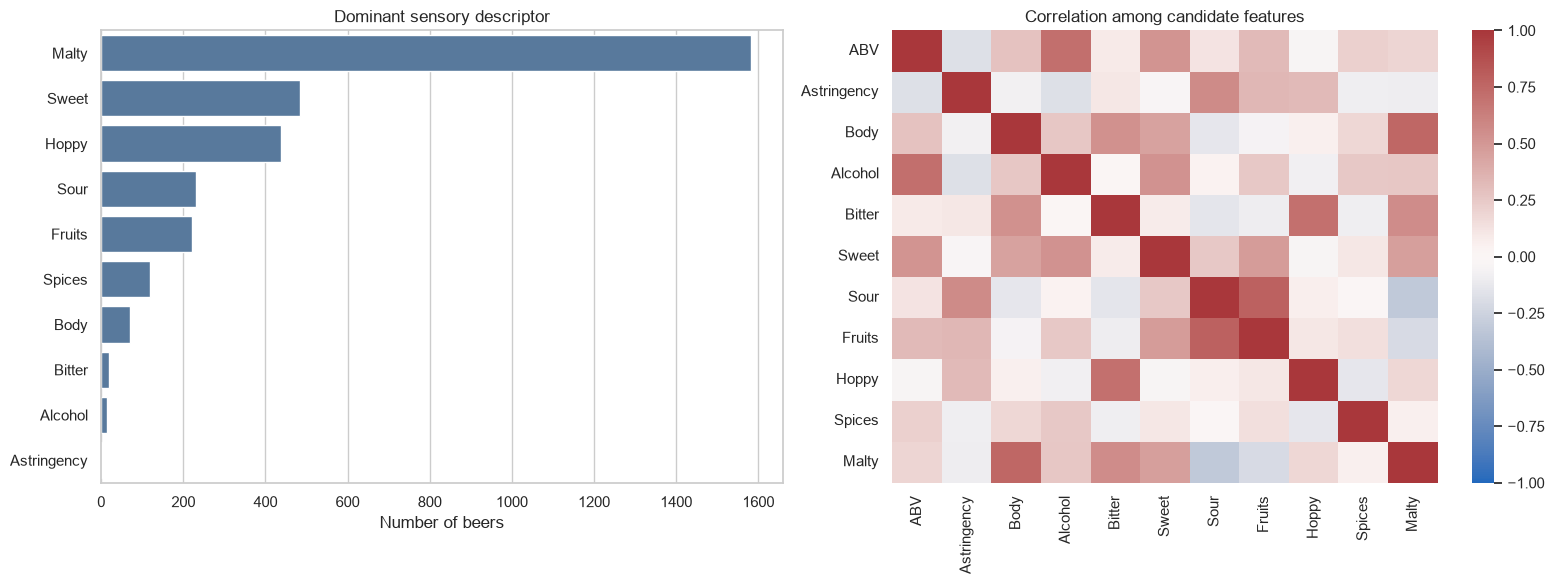

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

dominant_order = beer_clean["taste_category"].value_counts().index
sns.countplot(
    data=beer_clean,
    y="taste_category",
    order=dominant_order,
    color="#4C78A8",
    ax=axes[0],
)
axes[0].set_title("Dominant sensory descriptor")
axes[0].set_xlabel("Number of beers")
axes[0].set_ylabel("")

sns.heatmap(
    beer_clean[["ABV", *MODEL_SENSORY_COLS]].corr(),
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    ax=axes[1],
)
axes[1].set_title("Correlation among candidate features")

plt.tight_layout()
plt.show()

Malt is the most common dominant descriptor, while several related feature pairs—such as sour/fruit and bitter/hoppy—move together. These patterns suggest overlapping flavor dimensions rather than independent, sharply bounded categories.

## 5. Modeling Representation

A beer with more descriptor words can have larger counts in every category without having a fundamentally different flavor composition. In the retained data, total modeled sensory counts range from only a few words to several hundred. Column standardization alone does not remove that row-level count-volume effect.

We therefore:

1. divide each beer's sensory counts by its total to obtain a composition;
2. apply the square-root (Hellinger) transform, which handles zeros and makes Euclidean comparisons more suitable for compositions;
3. combine the transformed sensory profile with ABV;
4. standardize the resulting eleven model columns so ABV and each profile dimension have comparable variance.

In [7]:
sensory_counts = beer_clean[MODEL_SENSORY_COLS].astype(float)
profile_total = sensory_counts.sum(axis=1)
sensory_proportions = sensory_counts.div(profile_total, axis=0)
hellinger_profile = np.sqrt(sensory_proportions)

count_input = pd.concat([beer_clean[["ABV"]], sensory_counts], axis=1)
model_input = pd.concat([beer_clean[["ABV"]], hellinger_profile], axis=1)
MODEL_COLS = model_input.columns.tolist()

X_count_scaled = StandardScaler().fit_transform(count_input)
model_scaler = StandardScaler()
X_model = model_scaler.fit_transform(model_input)

assert X_model.shape == (len(beer_clean), 11)
assert np.isfinite(X_model).all()

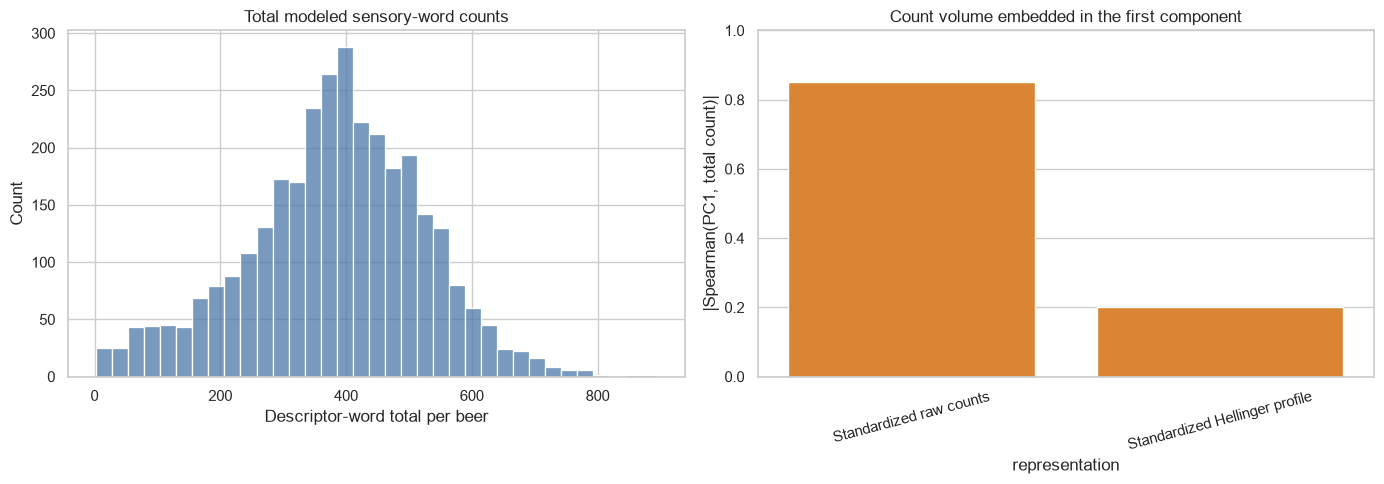

,representation,"|Spearman(PC1, total count)|",mean pairwise distance
0,Standardized raw counts,0.852,4.390
1,Standardized Hellinger profile,0.202,4.427


In [8]:
def pc1_count_association(matrix, totals):
    pc1 = PCA(n_components=1, random_state=RANDOM_STATE).fit_transform(matrix).ravel()
    return abs(spearmanr(pc1, totals).statistic)

representation_comparison = pd.DataFrame({
    "representation": ["Standardized raw counts", "Standardized Hellinger profile"],
    "|Spearman(PC1, total count)|": [
        pc1_count_association(X_count_scaled, profile_total),
        pc1_count_association(X_model, profile_total),
    ],
    "mean pairwise distance": [
        pdist(X_count_scaled).mean(),
        pdist(X_model).mean(),
    ],
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(profile_total, bins=35, color="#4C78A8", ax=axes[0])
axes[0].set_title("Total modeled sensory-word counts")
axes[0].set_xlabel("Descriptor-word total per beer")

sns.barplot(
    data=representation_comparison,
    x="representation",
    y="|Spearman(PC1, total count)|",
    color="#F58518",
    ax=axes[1],
)
axes[1].set_title("Count volume embedded in the first component")
axes[1].tick_params(axis="x", rotation=15)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()
representation_comparison.round(3)

The Hellinger representation substantially reduces the association between the leading component and total count volume. It is therefore used for every model below. This changes the meaning of distance from “similar absolute word counts” to “similar relative sensory profiles and ABV.”

## 6. Clusterability and Low-Dimensional Structure

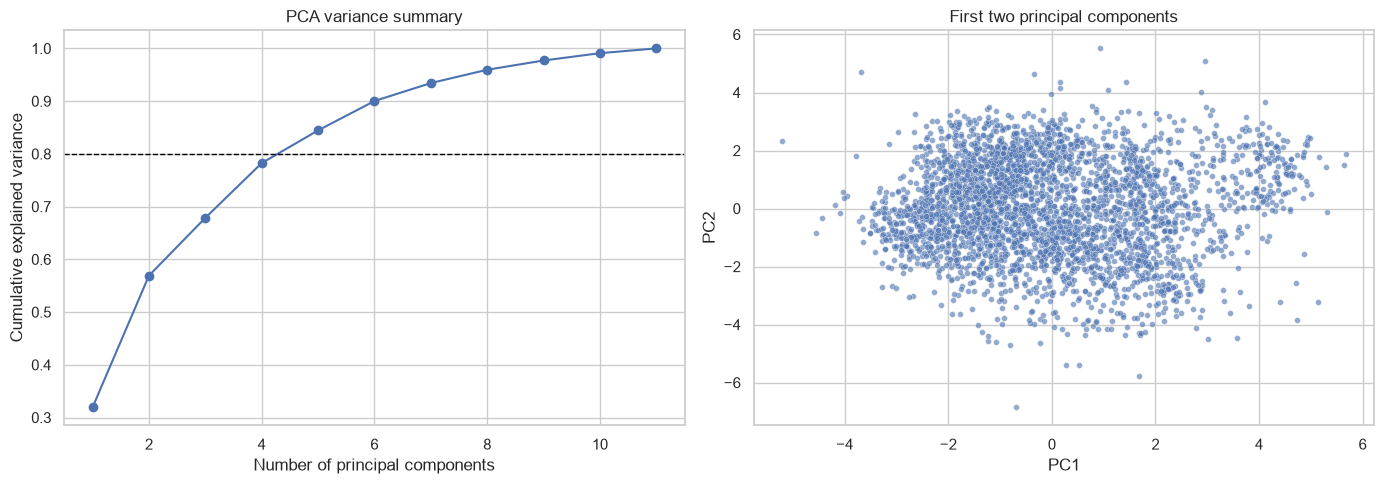

In [9]:
pca = PCA(random_state=RANDOM_STATE).fit(X_model)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
axes[0].axhline(0.80, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("Number of principal components")
axes[0].set_ylabel("Cumulative explained variance")
axes[0].set_title("PCA variance summary")

pca_scores = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_model)
sns.scatterplot(x=pca_scores[:, 0], y=pca_scores[:, 1], s=18, alpha=0.6, ax=axes[1])
axes[1].set_title("First two principal components")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

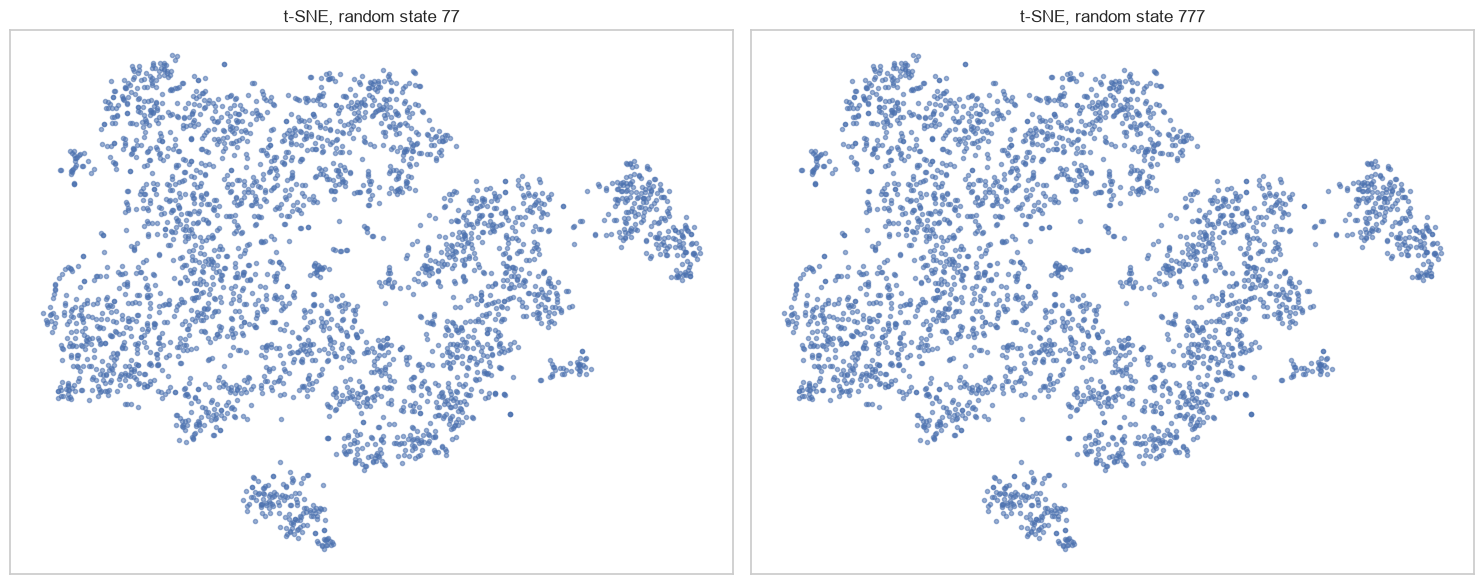

In [10]:
tsne_embeddings = {}
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, seed in zip(axes, [77, 777]):
    embedding = TSNE(
        n_components=2,
        perplexity=30,
        init="pca",
        learning_rate="auto",
        random_state=seed,
    ).fit_transform(X_model)
    tsne_embeddings[seed] = embedding
    ax.scatter(embedding[:, 0], embedding[:, 1], s=9, alpha=0.55)
    ax.set_title(f"t-SNE, random state {seed}")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

PCA and repeated t-SNE views show continuous bridges and overlapping regions, along with a visually distinctive sour/fruit region. Because t-SNE can exaggerate visual separation, it is used only as a display surface; model selection is performed in the full eleven-dimensional transformed space.

## 7. Model Comparison Strategy

- **K-means** provides a hard-clustering baseline.
- **DBSCAN** tests whether dense groups exist without requiring every beer to belong to a cluster.
- **Fuzzy C-means** is the main model because overlapping beer characteristics make partial membership scientifically meaningful.

Silhouette, Calinski–Harabasz, and Davies–Bouldin scores describe hard partitions. Fuzzy C-means is additionally evaluated using the fuzzy partition coefficient (FPC), partition entropy, and Xie–Beni index. No single statistic is treated as definitive.

### 7.1 K-means baseline

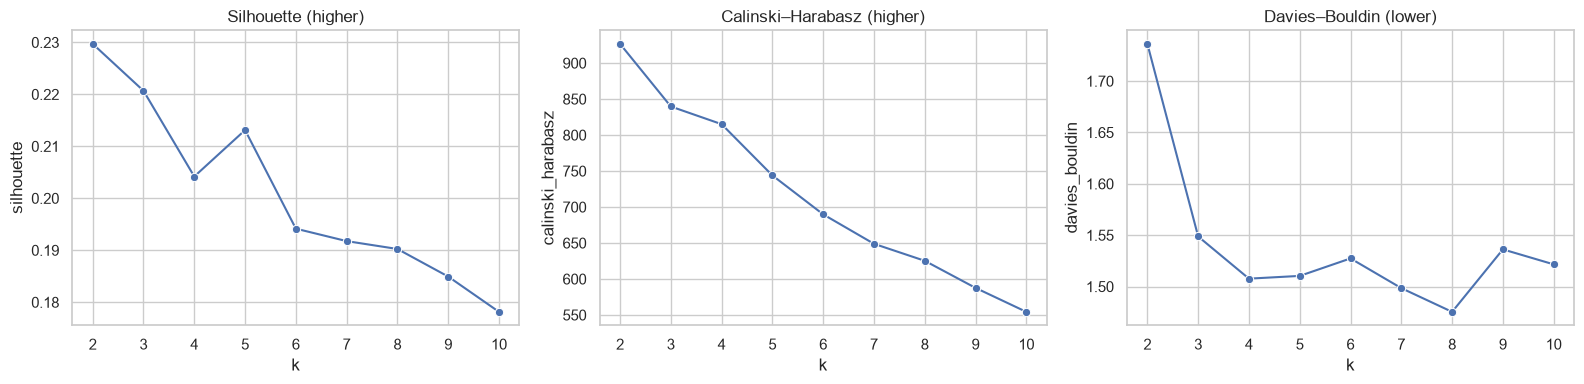

,k,silhouette,calinski_harabasz,davies_bouldin,smallest_cluster
0,2,0.230,926.673,1.736,1319
1,3,0.221,839.658,1.549,695
2,4,0.204,815.084,1.508,556
3,5,0.213,743.866,1.510,255
4,6,0.194,689.777,1.527,290
5,7,0.192,648.883,1.498,166
6,8,0.190,625.260,1.475,165
7,9,0.185,587.611,1.536,163
8,10,0.178,554.310,1.522,164


In [11]:
kmeans_rows = []
for k in range(2, 11):
    model = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_model)
    kmeans_rows.append({
        "k": k,
        "silhouette": silhouette_score(X_model, labels),
        "calinski_harabasz": calinski_harabasz_score(X_model, labels),
        "davies_bouldin": davies_bouldin_score(X_model, labels),
        "smallest_cluster": np.bincount(labels).min(),
    })

kmeans_results = pd.DataFrame(kmeans_rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric, title in zip(
    axes,
    ["silhouette", "calinski_harabasz", "davies_bouldin"],
    ["Silhouette (higher)", "Calinski–Harabasz (higher)", "Davies–Bouldin (lower)"],
):
    sns.lineplot(data=kmeans_results, x="k", y=metric, marker="o", ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()
kmeans_results.round(3)

K-means favors two clusters on silhouette and Calinski–Harabasz, indicating two broad flavor families. Scores decline only moderately at five clusters, suggesting that a finer partition may still be useful if it is stable and interpretable.

### 7.2 DBSCAN density structure

In [12]:
dbscan_rows = []
for min_samples, eps in itertools.product(
    [6, 12, 18, 24], np.arange(0.5, 3.01, 0.1)
):
    labels = DBSCAN(eps=float(eps), min_samples=min_samples).fit_predict(X_model)
    clustered = labels != -1
    cluster_ids = np.unique(labels[clustered])

    if len(cluster_ids) >= 2 and clustered.sum() > len(cluster_ids):
        cluster_sizes = pd.Series(labels[clustered]).value_counts()
        dbscan_rows.append({
            "eps": float(eps),
            "min_samples": min_samples,
            "clusters": len(cluster_ids),
            "coverage": clustered.mean(),
            "noise_points": int((~clustered).sum()),
            "silhouette_clustered": silhouette_score(
                X_model[clustered], labels[clustered]
            ),
            "smallest_cluster": int(cluster_sizes.min()),
        })

dbscan_results = pd.DataFrame(dbscan_rows)
dbscan_candidates = (
    dbscan_results
    .query("coverage >= 0.80 and smallest_cluster >= 25")
    .sort_values(["silhouette_clustered", "coverage"], ascending=False)
    .reset_index(drop=True)
)
dbscan_candidates.head(10).round(3)

,eps,min_samples,clusters,coverage,noise_points,silhouette_clustered,smallest_cluster
0,1.5,12,2,0.817,581,0.350,138
1,1.6,24,2,0.807,613,0.348,130
2,1.6,18,2,0.835,525,0.343,146


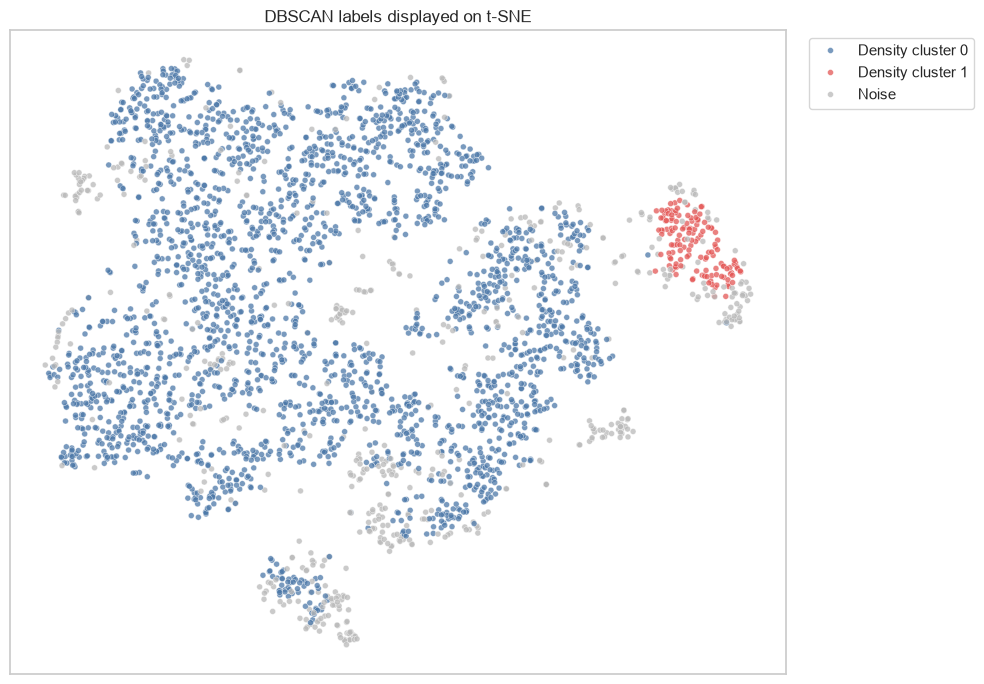

epsilon                             1.500
min_samples                        12.000
clusters                            2.000
coverage                            0.817
noise_points                      581.000
silhouette_on_clustered_points      0.350
dtype: float64

In [13]:
best_dbscan = dbscan_candidates.iloc[0]
dbscan_labels = DBSCAN(
    eps=float(best_dbscan["eps"]),
    min_samples=int(best_dbscan["min_samples"]),
).fit_predict(X_model)

dbscan_names = np.where(
    dbscan_labels == -1,
    "Noise",
    np.char.add("Density cluster ", dbscan_labels.astype(str)),
)
dbscan_summary = pd.Series({
    "epsilon": float(best_dbscan["eps"]),
    "min_samples": int(best_dbscan["min_samples"]),
    "clusters": int(best_dbscan["clusters"]),
    "coverage": float(best_dbscan["coverage"]),
    "noise_points": int(best_dbscan["noise_points"]),
    "silhouette_on_clustered_points": float(best_dbscan["silhouette_clustered"]),
})

embedding = tsne_embeddings[77]
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=dbscan_names,
    hue_order=["Density cluster 0", "Density cluster 1", "Noise"],
    palette=["#4C78A8", "#E45756", "#B9B9B9"],
    s=18,
    alpha=0.75,
)
plt.title("DBSCAN labels displayed on t-SNE")
plt.xticks([])
plt.yticks([])
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
dbscan_summary.round(3)

The selected DBSCAN configuration finds one large dense region and one small sour/fruit-rich core while leaving a substantial minority unassigned. DBSCAN therefore supports the existence of a distinctive local density cluster, but not a complete multi-group segmentation of the beer space.

### 7.3 Fuzzy C-means

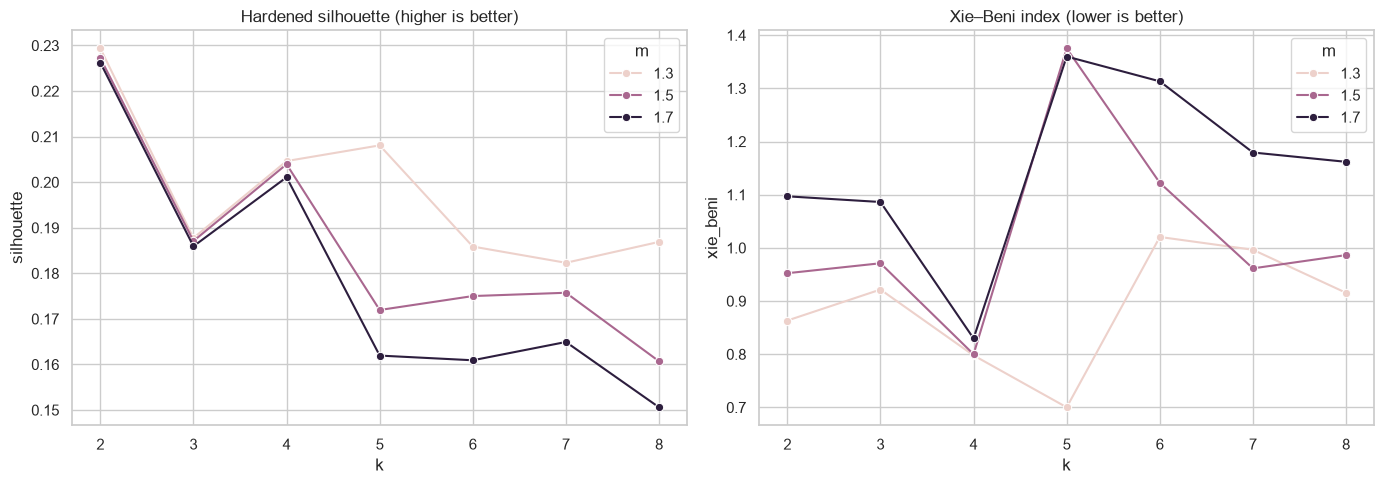

,k,m,silhouette,fpc,partition_entropy,xie_beni,iterations,smallest_cluster
9,5,1.3,0.208,0.741,0.505,0.700,114,252
6,4,1.3,0.205,0.761,0.451,0.798,55,544
7,4,1.5,0.204,0.587,0.786,0.800,66,562
8,4,1.7,0.201,0.442,1.045,0.830,77,623
0,2,1.3,0.229,0.832,0.276,0.863,39,1318
18,8,1.3,0.187,0.699,0.627,0.915,109,174
3,3,1.3,0.188,0.766,0.416,0.922,107,1011
1,2,1.5,0.227,0.718,0.439,0.952,47,1355
16,7,1.5,0.176,0.471,1.129,0.961,153,245
4,3,1.5,0.187,0.609,0.683,0.971,133,1034


In [14]:
def xie_beni_index(matrix, centers, membership, fuzziness):
    distances_sq = cdist(matrix, centers, metric="sqeuclidean").T
    numerator = np.sum((membership ** fuzziness) * distances_sq)
    minimum_center_separation = np.min(pdist(centers, metric="sqeuclidean"))
    return numerator / (len(matrix) * minimum_center_separation)


fuzzy_rows = []
for k, fuzziness in itertools.product(range(2, 9), [1.3, 1.5, 1.7]):
    centers, membership, _, _, objective, iterations, fpc = cmeans(
        X_model.T,
        c=k,
        m=fuzziness,
        error=1e-5,
        maxiter=2_000,
        seed=RANDOM_STATE,
    )
    hard_labels = membership.argmax(axis=0)
    partition_entropy = -np.sum(
        membership * np.log(membership + 1e-12)
    ) / len(X_model)

    fuzzy_rows.append({
        "k": k,
        "m": fuzziness,
        "silhouette": silhouette_score(X_model, hard_labels),
        "fpc": fpc,
        "partition_entropy": partition_entropy,
        "xie_beni": xie_beni_index(
            X_model, centers, membership, fuzziness
        ),
        "iterations": iterations,
        "smallest_cluster": np.bincount(hard_labels, minlength=k).min(),
    })

fuzzy_results = pd.DataFrame(fuzzy_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(
    data=fuzzy_results, x="k", y="silhouette", hue="m", marker="o", ax=axes[0]
)
axes[0].set_title("Hardened silhouette (higher is better)")
sns.lineplot(
    data=fuzzy_results, x="k", y="xie_beni", hue="m", marker="o", ax=axes[1]
)
axes[1].set_title("Xie–Beni index (lower is better)")
plt.tight_layout()
plt.show()

fuzzy_results.sort_values(["xie_beni", "silhouette"], ascending=[True, False]).head(10).round(3)

The fuzzy comparison reveals two useful resolutions. A two-cluster solution has the strongest silhouette and represents broad flavor families. The five-cluster solution with fuzziness parameter $m=1.3$ has the best Xie–Beni index in the tested grid, balanced cluster sizes, and a still-comparable silhouette. We select five clusters because the research question asks what interpretable flavor groupings emerge, while reporting the stronger two-family structure rather than hiding it.

## 8. Selected Five-Cluster Fuzzy Model

In [15]:
FINAL_K = 5
FINAL_M = 1.3

final_centers, final_membership, _, _, final_objective, final_iterations, final_fpc = cmeans(
    X_model.T,
    c=FINAL_K,
    m=FINAL_M,
    error=1e-5,
    maxiter=2_000,
    seed=RANDOM_STATE,
)

final_labels = final_membership.argmax(axis=0)
membership_confidence = final_membership.max(axis=0)

CLUSTER_NAMES = {
    0: "Strong / sweet-malty",
    1: "Fruity / spiced",
    2: "Sour / fruit-forward",
    3: "Bitter / hoppy",
    4: "Malty / full-bodied",
}

beer_results = beer_clean.copy()
beer_results["cluster"] = final_labels
beer_results["cluster_name"] = pd.Series(final_labels).map(CLUSTER_NAMES)
beer_results["membership_confidence"] = membership_confidence
for cluster in range(FINAL_K):
    beer_results[f"membership_{cluster}"] = final_membership[cluster]

selected_model_summary = pd.Series({
    "clusters": FINAL_K,
    "fuzziness_m": FINAL_M,
    "silhouette": silhouette_score(X_model, final_labels),
    "fuzzy_partition_coefficient": final_fpc,
    "iterations": final_iterations,
    "median_max_membership": np.median(membership_confidence),
    "share_max_membership_below_0.50": (membership_confidence < 0.50).mean(),
})
selected_model_summary.round(3)

clusters                             5.000
fuzziness_m                          1.300
silhouette                           0.208
fuzzy_partition_coefficient          0.741
iterations                         114.000
median_max_membership                0.896
share_max_membership_below_0.50      0.082
dtype: float64

In [16]:
stability_labels = []
for seed in [11, 29, 47, 71, 101]:
    _, seed_membership, _, _, _, _, _ = cmeans(
        X_model.T,
        c=FINAL_K,
        m=FINAL_M,
        error=1e-5,
        maxiter=2_000,
        seed=seed,
    )
    stability_labels.append(seed_membership.argmax(axis=0))

stability_ari = [
    adjusted_rand_score(first, second)
    for first, second in itertools.combinations(stability_labels, 2)
]

pd.Series({
    "mean pairwise ARI": np.mean(stability_ari),
    "minimum pairwise ARI": np.min(stability_ari),
    "maximum pairwise ARI": np.max(stability_ari),
}).round(3)

mean pairwise ARI       1.0
minimum pairwise ARI    1.0
maximum pairwise ARI    1.0
dtype: float64

The adjusted Rand index (ARI) compares hardened assignments across random initializations while ignoring arbitrary cluster-number permutations. Values near 1 indicate that the five-cluster solution is computationally stable, even though some individual beers retain mixed membership.

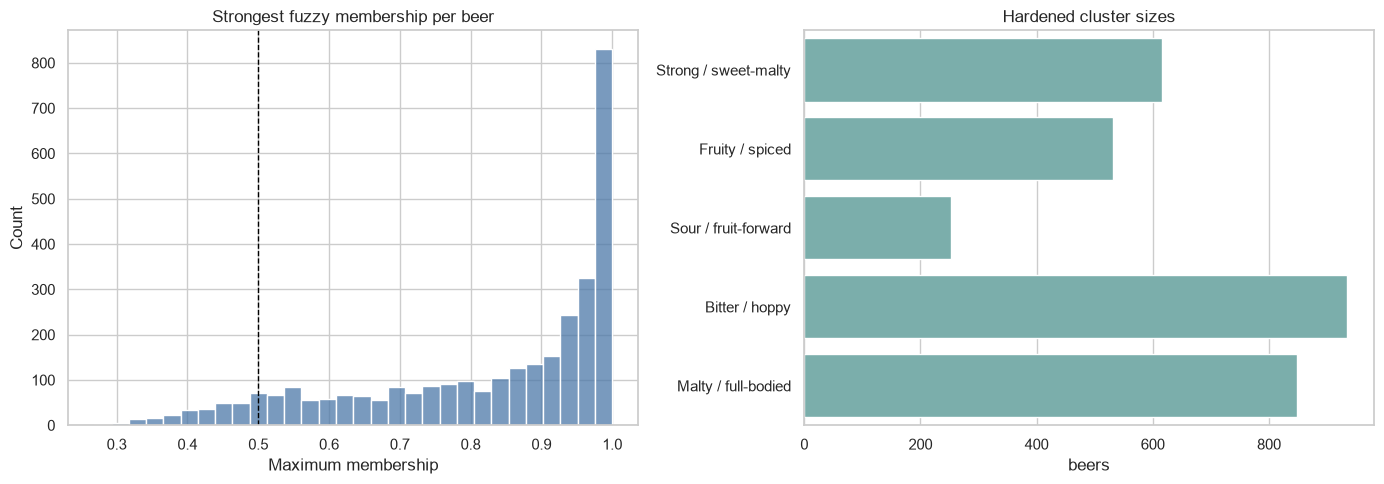

,cluster,beers
0,Strong / sweet-malty,616
1,Fruity / spiced,531
2,Sour / fruit-forward,252
3,Bitter / hoppy,934
4,Malty / full-bodied,849


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(membership_confidence, bins=30, color="#4C78A8", ax=axes[0])
axes[0].axvline(0.50, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Strongest fuzzy membership per beer")
axes[0].set_xlabel("Maximum membership")

cluster_sizes = (
    beer_results["cluster_name"]
    .value_counts()
    .reindex(CLUSTER_NAMES.values())
    .rename_axis("cluster")
    .reset_index(name="beers")
)
sns.barplot(data=cluster_sizes, y="cluster", x="beers", color="#72B7B2", ax=axes[1])
axes[1].set_title("Hardened cluster sizes")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()
cluster_sizes

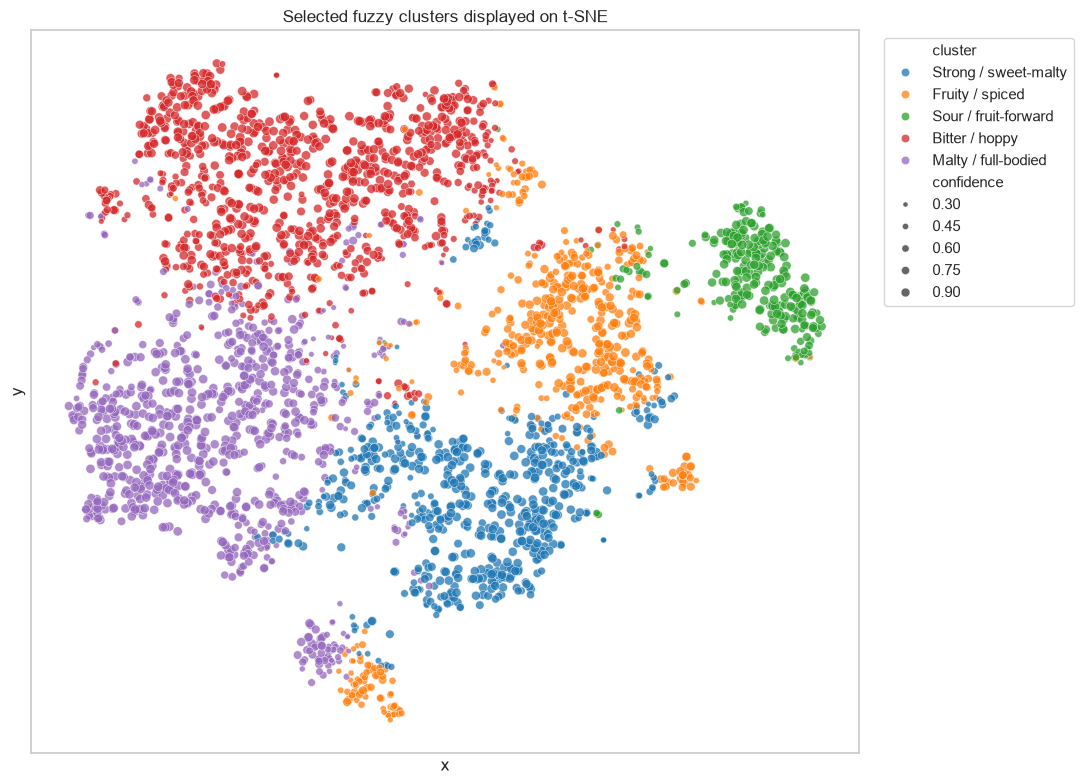

In [18]:
embedding = tsne_embeddings[77]
plot_frame = pd.DataFrame({
    "x": embedding[:, 0],
    "y": embedding[:, 1],
    "cluster": beer_results["cluster_name"],
    "confidence": membership_confidence,
})

plt.figure(figsize=(11, 8))
sns.scatterplot(
    data=plot_frame,
    x="x",
    y="y",
    hue="cluster",
    hue_order=list(CLUSTER_NAMES.values()),
    palette="tab10",
    size="confidence",
    sizes=(12, 45),
    alpha=0.75,
)
plt.title("Selected fuzzy clusters displayed on t-SNE")
plt.xticks([])
plt.yticks([])
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

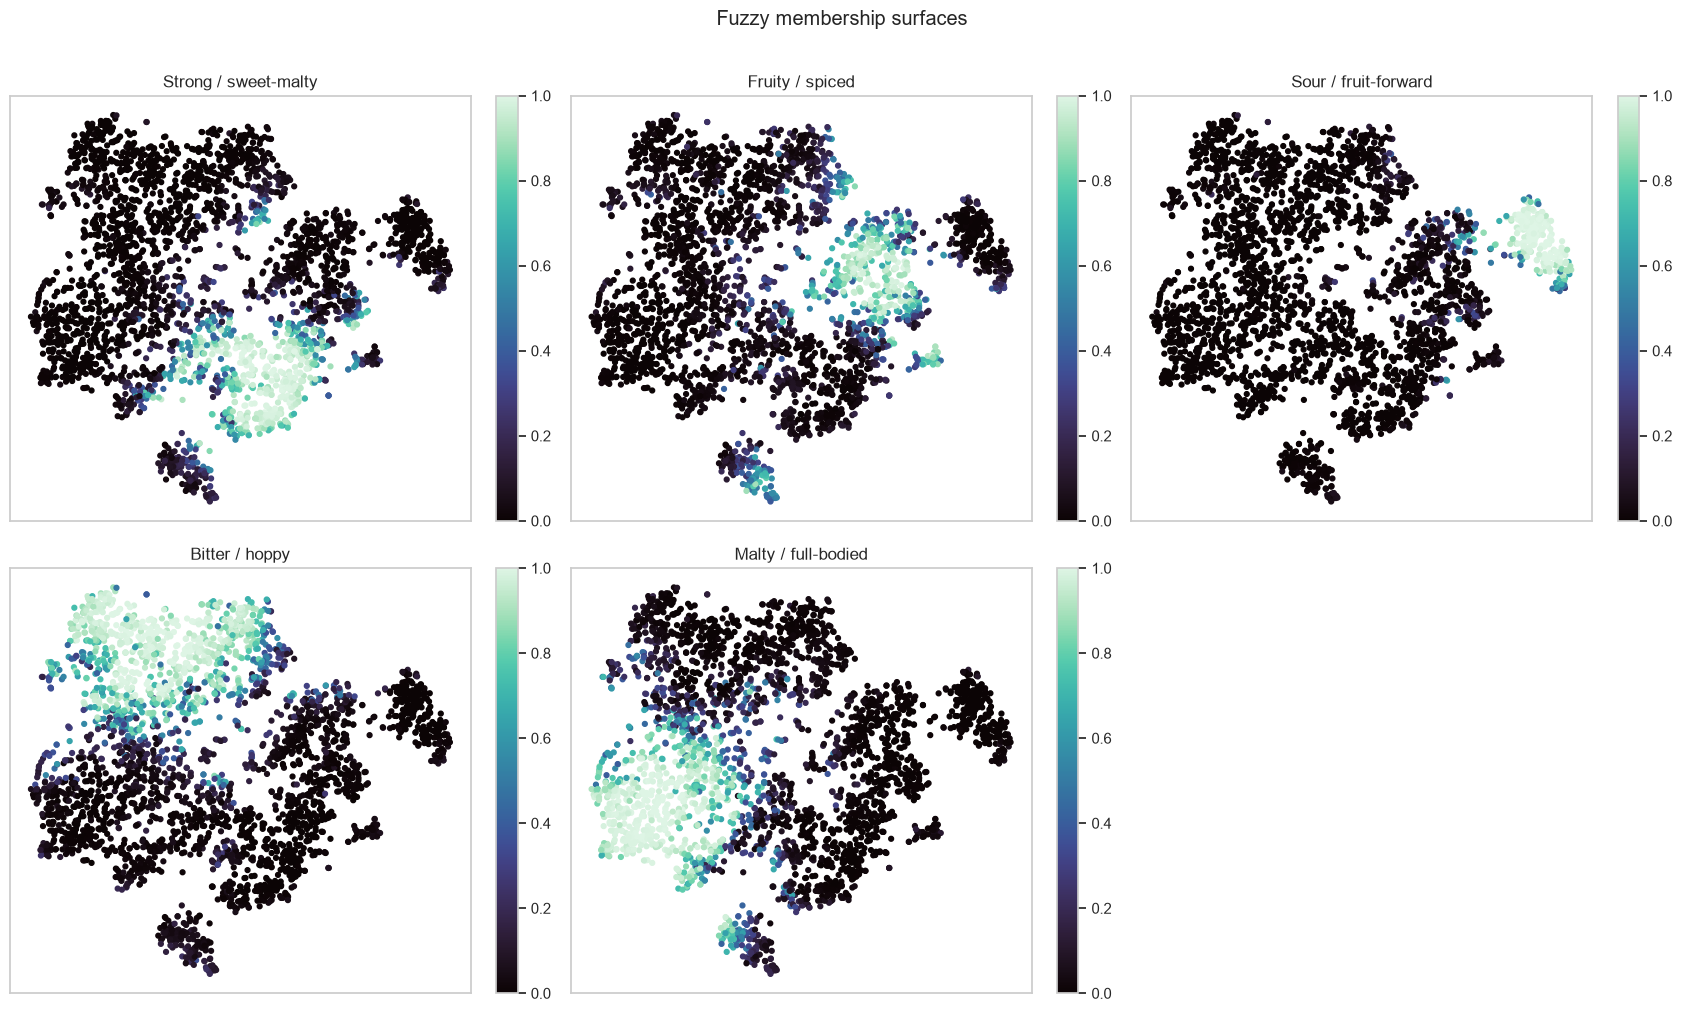

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10), sharex=True, sharey=True)
axes = axes.ravel()

for cluster, ax in enumerate(axes[:FINAL_K]):
    points = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=final_membership[cluster],
        cmap="mako",
        vmin=0,
        vmax=1,
        s=12,
    )
    ax.set_title(CLUSTER_NAMES[cluster])
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(points, ax=ax, fraction=0.046)

axes[-1].axis("off")
fig.suptitle("Fuzzy membership surfaces", y=1.01)
plt.tight_layout()
plt.show()

## 9. Interpreting the Five Flavor Groups

In [20]:
profile_frame = sensory_proportions.copy()
profile_frame["ABV"] = beer_clean["ABV"].to_numpy()
profile_frame["cluster"] = final_labels

cluster_profiles = profile_frame.groupby("cluster").mean()
cluster_profiles.index = cluster_profiles.index.map(CLUSTER_NAMES)
cluster_profiles.index.name = "cluster"

profile_display = cluster_profiles[["ABV", *MODEL_SENSORY_COLS]].copy()
profile_display[MODEL_SENSORY_COLS] = profile_display[MODEL_SENSORY_COLS].mul(100)
profile_display = profile_display.rename(
    columns={column: f"{column} %" for column in MODEL_SENSORY_COLS}
)
profile_display.round(2)

,ABV,Astringency %,Body %,Alcohol %,Bitter %,Sweet %,Sour %,Fruits %,Hoppy %,Spices %,Malty %
cluster,,,,,,,,,,,
Strong / sweet-malty,9.49,2.37,11.77,9.74,6.34,20.92,6.47,10.93,6.21,5.34,19.91
Fruity / spiced,6.18,4.55,10.16,4.12,5.73,13.05,11.32,14.94,8.50,12.28,15.36
Sour / fruit-forward,6.12,7.23,7.79,2.42,2.29,17.27,29.11,21.30,3.95,2.19,6.45
Bitter / hoppy,5.47,6.64,9.94,2.73,13.14,10.86,7.45,8.05,19.24,2.19,19.77
Malty / full-bodied,5.77,3.71,17.66,3.03,12.09,15.72,3.15,3.66,8.98,3.61,28.39


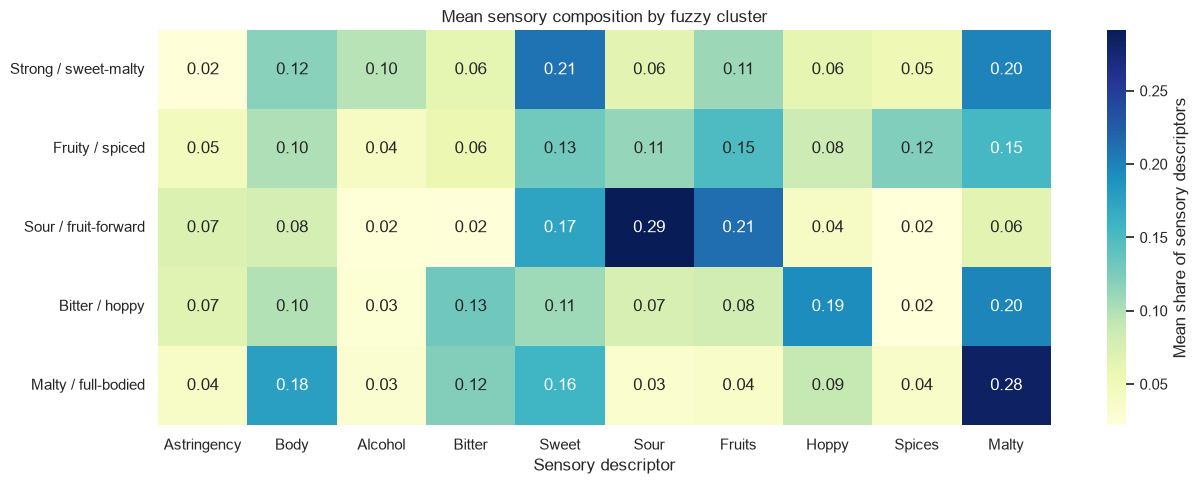

In [21]:
plt.figure(figsize=(13, 5))
sns.heatmap(
    cluster_profiles[MODEL_SENSORY_COLS],
    cmap="YlGnBu",
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Mean share of sensory descriptors"},
)
plt.title("Mean sensory composition by fuzzy cluster")
plt.xlabel("Sensory descriptor")
plt.ylabel("")
plt.tight_layout()
plt.show()

The selected clusters have clear relative profiles:

- **Strong / sweet-malty:** highest mean ABV, with sweet and malt descriptors.
- **Fruity / spiced:** fruit, spice, and wheat/Belgian-style tendencies.
- **Sour / fruit-forward:** the strongest sour and fruit proportions and the most distinct local region.
- **Bitter / hoppy:** elevated bitter and hop descriptors.
- **Malty / full-bodied:** the largest malt and body proportions.

These names summarize average profiles; they are not official beer-style labels.

In [22]:
representative_rows = []
for cluster in range(FINAL_K):
    distances = np.linalg.norm(X_model - final_centers[cluster], axis=1)
    members = np.flatnonzero(final_labels == cluster)
    nearest_members = members[np.argsort(distances[members])[:3]]

    for rank, row_index in enumerate(nearest_members, start=1):
        representative_rows.append({
            "cluster": CLUSTER_NAMES[cluster],
            "rank": rank,
            "beer": beer_clean.loc[row_index, "Beer Name (Full)"],
            "style": beer_clean.loc[row_index, "Style"],
            "ABV": beer_clean.loc[row_index, "ABV"],
            "membership": final_membership[cluster, row_index],
        })

representative_beers = pd.DataFrame(representative_rows)
representative_beers.round({"ABV": 2, "membership": 3})

,cluster,rank,beer,style,ABV,membership
0,Strong / sweet-malty,1,Eel River Brewing Co. Triple Exultation,Old Ale,9.70,1.000
1,Strong / sweet-malty,2,Grand Teton Brewing Co. Bone Warmer Amber Ale,Red Ale - Imperial,8.20,1.000
2,Strong / sweet-malty,3,Brasserie de l'Abbaye des Rocs s.a. Abbaye Des...,Strong Ale - Belgian Dark,9.00,0.999
3,Fruity / spiced,1,Hacker-Pschorr Bräu GmbH Hacker-Pschorr Krista...,Wheat Beer - Kristallweizen,5.50,1.000
4,Fruity / spiced,2,Brouwerij 't IJ Natte,Dubbel,6.50,0.996
5,Fruity / spiced,3,Unibroue Raftman,Pale Ale - Belgian,5.50,0.999
6,Sour / fruit-forward,1,LoverBeer Madamin,Sour - Flanders Oud Bruin,5.70,1.000
7,Sour / fruit-forward,2,Brouwerij Van Steenberge N.V. Monk's Café Flem...,Sour - Flanders Oud Bruin,5.50,1.000
8,Sour / fruit-forward,3,Jolly Pumpkin Artisan Ales Bière De Mars,Farmhouse Ale - Bière de Garde,7.00,1.000
9,Bitter / hoppy,1,Rock Bottom Restaurant & Brewery Fire Chief Ale,Red Ale - Irish,5.50,1.000


In [23]:
style_rows = []
for cluster in range(FINAL_K):
    cluster_mask = final_labels == cluster
    style_counts = beer_clean.loc[cluster_mask, "Style"].value_counts().head(5)
    cluster_size = cluster_mask.sum()

    for rank, (style, count) in enumerate(style_counts.items(), start=1):
        style_rows.append({
            "cluster": CLUSTER_NAMES[cluster],
            "rank": rank,
            "style": style,
            "beers": count,
            "within_cluster_percent": 100 * count / cluster_size,
        })

top_styles = pd.DataFrame(style_rows)
top_styles.round({"within_cluster_percent": 1})

,cluster,rank,style,beers,within_cluster_percent
0,Strong / sweet-malty,1,Strong Ale - Belgian Dark,39,6.3
1,Strong / sweet-malty,2,Barleywine - American,37,6.0
2,Strong / sweet-malty,3,Bock - Doppelbock,34,5.5
3,Strong / sweet-malty,4,Quadrupel (Quad),34,5.5
4,Strong / sweet-malty,5,Scotch Ale / Wee Heavy,34,5.5
5,Fruity / spiced,1,Wheat Beer - Hefeweizen,41,7.7
6,Fruity / spiced,2,Blonde Ale - Belgian,31,5.8
7,Fruity / spiced,3,Wheat Beer - Witbier,31,5.8
8,Fruity / spiced,4,Wheat Beer - Dunkelweizen,30,5.6
9,Fruity / spiced,5,Pale Ale - Belgian,27,5.1


### Relationship between DBSCAN and the fuzzy groups

In [24]:
dbscan_display = pd.Series(dbscan_names, name="DBSCAN result")
comparison_table = pd.crosstab(
    beer_results["cluster_name"],
    dbscan_display,
    normalize="index",
).mul(100)
comparison_table.round(1)

DBSCAN result,Density cluster 0,Density cluster 1,Noise
cluster_name,,,
Bitter / hoppy,91.9,0.0,8.1
Fruity / spiced,72.5,0.0,27.5
Malty / full-bodied,85.5,0.0,14.5
Sour / fruit-forward,3.6,54.8,41.7
Strong / sweet-malty,78.7,0.0,21.3


DBSCAN's small density cluster is concentrated in the fuzzy **Sour / fruit-forward** group. This agreement strengthens the interpretation that sour-fruit beers form the clearest local grouping. The remaining fuzzy groups are better understood as overlapping regions within a connected flavor space than as isolated density islands.

## 10. Discussion

### Research question 1: Can the beers be meaningfully grouped?

Yes, with qualifications. The strongest hard-partition evidence favors **two broad families**, and both K-means and a two-cluster fuzzy model are highly stable. A five-cluster fuzzy solution provides a stable and interpretable finer description, but its silhouette is modest. The beers therefore exhibit meaningful tendencies inside a largely continuous and overlapping flavor space—not five perfectly separated natural species.

DBSCAN reinforces this conclusion. It identifies a compact sour/fruit-rich core, a large main density region, and many boundary or low-density beers. That is evidence for one especially distinctive flavor island, not for a clean density-based partition of the whole dataset.

### Research question 2: What groupings emerge?

At the finer resolution, the five profiles are strong/sweet-malty, fruity/spiced, sour/fruit-forward, bitter/hoppy, and malty/full-bodied. The fuzzy memberships preserve cross-profile beers rather than forcing every observation to be equally certain.

## 11. Limitations

- Sensory variables are review-word counts, so they reflect language and reviewer behavior as well as beer characteristics.
- Hellinger normalization emphasizes relative flavor composition and intentionally removes absolute descriptor volume.
- `Salty` and beers above 20% ABV were excluded from the model; alternative scope choices should be checked in future sensitivity analyses.
- t-SNE is a visualization method and cannot establish cluster validity.
- Dominant descriptors and beer styles are used only for interpretation; neither is ground truth for the unsupervised clusters.
- The dataset is not a representative census of all beers or breweries.

## 12. Conclusion

Beer flavor in this dataset is best described as a connected spectrum with reproducible regions. Two broad families provide the strongest separation, while five fuzzy clusters offer a useful descriptive vocabulary for finer structure. The sour/fruit-forward group is the most locally distinct; the other groups overlap through beers with mixed sensory profiles.

This result favors fuzzy recommendations over rigid classification. A recommendation system could use the full membership vector to find nearby beers or suggest controlled transitions between flavor regions, while clearly communicating uncertainty for boundary beers.

## References

1. ruthgn. *Beer Profile and Ratings Data Set*. Kaggle, 2021. https://www.kaggle.com/datasets/ruthgn/beer-profile-and-ratings-data-set
2. Bezdek, J. C., Ehrlich, R., & Full, W. “FCM: The Fuzzy C-Means Clustering Algorithm.” *Computers & Geosciences*, 10(2–3), 191–203, 1984.
3. Ester, M., Kriegel, H.-P., Sander, J., & Xu, X. “A Density-Based Algorithm for Discovering Clusters in Large Spatial Databases with Noise.” *KDD*, 1996.
4. Rousseeuw, P. J. “Silhouettes: A Graphical Aid to the Interpretation and Validation of Cluster Analysis.” *Journal of Computational and Applied Mathematics*, 20, 53–65, 1987.
5. van der Maaten, L., & Hinton, G. “Visualizing Data Using t-SNE.” *Journal of Machine Learning Research*, 9, 2579–2605, 2008.